<h1> SIR models of disease dynamics </h1>

<h2>Table of Contents</h2>

- [Outcome](#Outcome)
- [SIR Models: the concepts](#SIR-Models:-the-concepts)
- [SIR Models: the equations](#SIR-Models:-the-equations)
- [Julia code: the function for one time-step](#Julia-code:-the-function-for-one-time-step)
- [Julia code: the loop structure](#Julia-code:-the-loop-structure)
- [Running the model](#Running-the-model)
- [Plotting the results](#Plotting-the-results)


[Back to the top](#In-this-lecture)

<h2>Outcome</h2>

After this lecture, you will be able to
- Define the compartments S, I and R of an SIR
- Formulate an SIR model for infectious diseases
- Write a "for" loop to for an SIR model 
- Plot the curves for S(t), I(t) and R(t)

[Back to the top](#Table-of-Contents)

<h2>SIR Models: the concepts</h2>

SIR models formalise what is probably the simplest possible way to think of an epidemic: 
- before the epidemic starts, there is a population at risk of catching the disease
- the disease spreads from infected to susceptible people
- after a while, people are no longer infected
- once infected, people are never infected again
- we ignore all other differences between people

We use the symbol $S$ for the number of people who are still at risk of the disease. "$S$" is short for "susceptible", meaning a person who hasn't had the disease and might catch it. We think of $S$ as a function of time, that is, we think that as the epidemic progresses, $S$ changes. Therefore we write $S(t)$ for the number of suseptibles at time $t$.

The number $S(0)$, which is the number of susceptibles at the start of the epidemic, is a key value in this model.

The number of infected people at time $t$ is given by $I(t)$. We assume that $I(0) > 0$, because otherwise the epidemic can't start.

Finally, the people previously infected but no longer infectious are called "removed". (Unfortunately, this doesn't mean they've recovered. They may still be ill, or as happens tragically often with Ebola, they may be dead). We use $R(t)$ to symbolise the number of removed people  at time $t$.


[Back to the top](#Table-of-Contents)

**NB! It is not necessary for S, I and R to be whole numbers. ** This is a model, and all we want is for the predicted values of $S$, $I$ and $R$ to be close to what is observed. By close we mean within a few percent. In fact, because the models are so simple and the real situation so variable, getting numbers within a few percent is a major achievement.

Unfortunately, this is usually possible only with  hindsight. We will show that an SIR model can do pretty well for the 2014 West African EVD epidemic, but it will be with hindsight. The course of the epidemic was not successfully predicted until it was nearly over.

[Back to the top](#Table-of-Contents)

<h2>SIR Models: the equations</h2>

We will model $S$, $I$ and $R$ in discrete time steps. In fact, we will use the same length of time step $dt$ for every step. We denote by $t_i$ the time after $i$ steps. Since we assume that $t_0 = 0$, we have $t_i = i\,dt$.

The model steps from $t_i$ to $t_{i+1}$, so what we want to do is use the values of $S(t_i)$, $I(t_i)$ and $R(t_i)$ to predict the values $S(t_{i+1})$, $I(t_{i+1})$ and $R(t_{i+1})$. So our model is set up in terms of three equations.

These equations all have the form "new value = old value + gains - losses". The model specifies how we calculate the gains and losses.

For susceptibles, there is only a loss term. The simplest SIR models come from the so-called "law of mass action". This law holds that all susceptibles have an equal chance of meeting an infected person. And the same is assumed for infected people. Then the number of  meetings of infecteds and susceptibles is proportional to product $SI$. We use the symbol $\lambda$ for the constant of proportionality, and we interpret $\lambda SI$ as the rate at which susceptibles become infected. This is of course a rate per day. So the actual loss over the time step $dt$ is actually $\lambda SI\,dt$ so the equation for $S$ is

1 ...     $ S(t_{i+1}) = S(t_i) - \lambda S(t_i)I(t_i)\,dt$.

On the other hand, the loss rate for infected people is just a constant probability of recovery per unit time. So a constant fraction $\gamma$ is removed from the infecteds per day. This gives a loss of $\gamma I$ infecteds per day, which is $\gamma I\,dt$ loss of infecteds per time step. The gain of infecteds must be exactly the susceptibles who become infected, so the equation for $I$ is

2 ...     $I(t_{i+1}) = I(t_i) + \lambda S(t_i)I(t_i)\,dt - \gamma I(t_i)\,dt$.

In an SIR model, the removed population equation has only a gain term, no loss term. What is lost from infecteds is gained by removeds, so the equation for $R$ is

3 ...     $R(t_{i+1}) = R(t_i) + \gamma I(t_i)\,dt$.

Our discrete SIR model consists of equations 1, 2 and 3 for $S$, $I$, $R$.

[Back to the top](#Table-of-Contents)

<h2>Julia code: the function for one time-step</h2>

So now we consider the best way to write the Julia code. We have several options: we could write a "for" loop with the three equations inside; we could make three functions, one for each of $S$, $I$ and $R$; we could combine all three into one array and write one function to update all three at the same time. We will do that here.

**Julia functions have access to all variables that are visible at the level that the function is created**

This feature of Julia will surprise many experienced programmers. If we assign a value to the variable b and then call a function that uses b without mentioning b in the argument of the function, the function will nevertheless use the value of b as needed. See below:


In [ ]:
b = 4; # GLOBAL variable

function f(x)
    #b = 1 # you can assign LOCAL b here
    y = b*x # Julia can access global variables (i.e. b) inside the functions
    #b = 5 # you can NOT assign LOCAL b here, results in UndefVarError: b not defined
    return y
end

println( "The function returns ", f(6) )
println("The value of b is ", b)

[Back to the top](#Table-of-Contents)
<hr/>

# Define Function update(SIR)

We will use this feature to pass the values of **λ (lambda)**  and **γ (gamma)** to the updating function. That is, in writing the code for the function, we pass it only the $S$, $I$, $R$ arguments and take the parameter values from the context in which the function is called. This is actually amazingly convenient, especially when we want to experiment with different parameter values for  the sake of fitting the model output to the data.

This means the function looks like this:

In [79]:
function update(sir::Array{Float64,2}) # takes 1×4 Array{Float64,2} 4 columns
    println("input ", sir)
    days       = sir[1];
    suseptible = sir[2];
    infected   = sir[3]; 
    removed    = sir[4];
    
    # GLOBAL variables:
    # λ (lambda) :  rate of infection
    # γ (gamma)  :  rate of removal (recovered or dead)
    
    newly_infected  = suseptible*λ*infected*days
    println("newly_infected ", newly_infected)
    
    newly_removed   = γ*infected*days
    println("newly_removed ", newly_removed)
    
    suseptible_update = suseptible - newly_infected
    println("suseptible_update ", suseptible_update)
    
    infected_update = infected + newly_infected - newly_removed
    println("infected_update ", infected_update)
    
    removed_update = removed + newly_removed
    println("removed_update ", removed_update)
    
    return [ days+1 suseptible_update infected_update removed_update ]   # returns 1×4 Array{Float64,2} 4 columns
end

λ = 1/20000    # infection rate
γ = 1/10     # removal rate
sir = [1.0 70.0 20.0 10.0]
update(sir)

input [1.0 70.0 20.0 10.0]
newly_infected 0.07
newly_removed 2.0
suseptible_update 69.93
infected_update 18.07
removed_update 12.0


1×4 Array{Float64,2}:
 2.0  69.93  18.07  12.0

# Function testing
One should always do at least minimal checking that a function works as expected. 

For professional code, one should do extensive checking, both of output and input ... one should in fact write the function so that if it fails, it fails  gracefully, and give it some protection against error conditions. But we're not writing professional code!

On the other hand, let us take the opportunity also to illustrate some typical bugs and how to meet them.

In [80]:
# https://docs.julialang.org/en/v1/stdlib/Test/

π ≈ 3.14159265 # compare to 8 decimal places

using Test
sir = [0.0 70.0 20.0 10.0]
λ = 1/20000    # infection rate per day
γ = 90/10/16     # removal (recovery and death) rate per day; ebola has 80 to 90% death rate up to 16 days after infection
println("removal rate ", γ)

sir = [1.0 70.0 20.0 10.0]
@test update(sir) ≈ [2.0 58.33333333333333 31.533333333333335 10.133333333333333]
update(sir)

sir = [2.0 52.5  37.48  10.02]
update(sir)
#@test update(sir) ≈ [3.0 17.5  72.44  10.06]

#sir = [3.0 17.5  72.44  10.06]
#@test update(sir) == [4.0 0.0  89.92  10.08]

removal rate 0.5625
input [1.0 70.0 20.0 10.0]
newly_infected 0.07
newly_removed 11.25
suseptible_update 69.93
infected_update 8.82
removed_update 21.25
Test Failed at In[80]:12
  Expression: update(sir) ≈ [2.0 58.33333333333333 31.533333333333335 10.133333333333333]
   Evaluated: [2.0 69.93 8.82 21.25] ≈ [2.0 58.33333333333333 31.533333333333335 10.133333333333333]


Test.FallbackTestSetException: There was an error during testing

# Initialize the Values

In [67]:
# first we set the parameters
days = 1
days_total = 610; 
intervals = round(Int64, days_total/days) 
println("intervals:", intervals)

sir = Array{Float64}(undef, intervals+1, 4) # declare with: undefined values, rows, columns
sir = fill(0.0, intervals+1, 4) # fill with "0.0"

s0 = 10000.0     # S(nought):initial susceptible
i0 = 4.0         # I(nought):initial infected
r0 = 0.0         # R(nought):initial removed
λ = 1/20000      # infection rate
γ = 1/10         # removal rate

total_population = s0 + i0 + r0

sir[1,:] = [1.0 s0 i0 r0] # populate first row with starting numbers
sir[1:3,:]

intervals:610


3×4 Array{Float64,2}:
 1.0  10000.0  4.0  0.0
 0.0      0.0  0.0  0.0
 0.0      0.0  0.0  0.0

[Back to the top](#Table-of-Contents)

<h2>Julia code: the loop structure</h2>

Now we consider the loop structure. We can't run the model indefinitely, of course, so there has to be a definite end time $T_f$. We will use $T_f=610$ days, which is just a little more than the number of epidemic days in the data from Wikipedia.

The number of steps is then in principle $n = T_f/dt$, but here is a delicate moment in the use of computers. Computer arithmetic is not infinitely precise, and so we cannot be quite sure that if we use the computer to calculate $n$ in this way that we will exactly have $n\,dt = T_f$ as we expect on the grounds of algebra. I like to set time as a separate variable, to keep explicit track of step number $i$, and to continue for $n$ steps. Then if at the end the time is not exactly $T_f$ it doesn't matter, because it will be extremely close to it.

The take-home message is DO NOT RELY ON EXACT EQUALITY, even if you can reasonably expect it. Computers normally are only very close to the numbers you, the programmer, are thinking of (excluding again the exactness that professional programmers may sometimes achieve).

Knowing the value of $n$ also allows us to initialise an array to hold all the values as they're collected, one row of three elements for each value of the time. This will end up being $n+1$ values, of course.

So here is the concept code:

[Back to the top](#Table-of-Contents)
<hr/>

<h2>Running the model</h2>

We can now run the model. To illustrate the steps, I paste the  cell above into the cell below, and supply the missing bits, this includes the parameter values that we set up before, but not the updateSIR function, as we do not wish to modify that.

In [69]:
for row = 1:intervals
    input =[sir[row,1] sir[row,2] sir[row,3] sir[row,4]]
    results = update(input)
    s = results[1] # resulting Suseptible
    i = results[2] # resulting Infected
    r = results[3] # resulting Removed
    
    if total_population > s+i+r 
        println("total_population ", total_population, " is bigger than ", s+i+r, " math is wrong!")
        break
    end
    
        
    if total_population < s+i+r 
        println("total_population ", total_population, " is smaller than ", s+i+r, " math is wrong!")
        break
    end
    
    if s < 1 # nobody to infect, epidemic ends
        println("for input ", input, "results are ", results)
        println("nobody to infect, epidemic ends")
        break
    end
    
    if i < 1 # no infected people, epidemic ends
        println("for input ", input, "results are ", results)
        println("no infected people, epidemic ends")
        break
    end
    
    # assign 
    sir[row+1,1] = row+1      # next row number
    sir[row+1,2] = s          # resulting S
    sir[row+1,3] = i          # resulting I
    sir[row+1,4] = r          # resulting R
end
sir # derived table

total_population 10004.0 is smaller than 10005.6 math is wrong!


611×4 Array{Float64,2}:
 1.0  10000.0  4.0  0.0
 0.0      0.0  0.0  0.0
 0.0      0.0  0.0  0.0
 0.0      0.0  0.0  0.0
 0.0      0.0  0.0  0.0
 0.0      0.0  0.0  0.0
 0.0      0.0  0.0  0.0
 0.0      0.0  0.0  0.0
 0.0      0.0  0.0  0.0
 0.0      0.0  0.0  0.0
 0.0      0.0  0.0  0.0
 0.0      0.0  0.0  0.0
 0.0      0.0  0.0  0.0
 ⋮                  
 0.0      0.0  0.0  0.0
 0.0      0.0  0.0  0.0
 0.0      0.0  0.0  0.0
 0.0      0.0  0.0  0.0
 0.0      0.0  0.0  0.0
 0.0      0.0  0.0  0.0
 0.0      0.0  0.0  0.0
 0.0      0.0  0.0  0.0
 0.0      0.0  0.0  0.0
 0.0      0.0  0.0  0.0
 0.0      0.0  0.0  0.0
 0.0      0.0  0.0  0.0

[Back to the top](#Table-of-Contents)
<hr/>

<h2>Plotting the results</h2>

It is now simple  to plot the three population components versus the time.



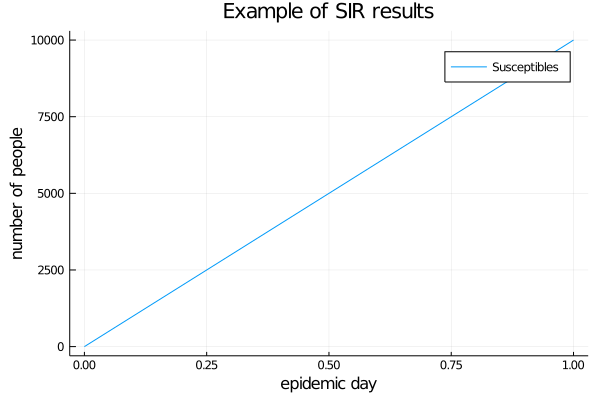

In [70]:
using Plots
gr()
plot(sir[:,1], sir[:,2],
title  = "Example of SIR results",
xlabel = "epidemic day",
ylabel = "number of people",
label  = ["Susceptibles" "Infecteds" "Removeds"]
)

[Back to the top](#Table-of-Contents)
<hr/>